In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv(r"C:\Users\ramya\OneDrive\Desktop\Stock Market prediction project\apple_feature_engineered.csv")

In [3]:
print(df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return',
       'MA20', 'MA50', 'Target', 'Sentiment', 'Positive_Sentiment',
       'Negative_Sentiment', 'Neutral_Sentiment', 'article_count', 'Lag1',
       'Lag2', 'Lag3', 'Lag5', 'RSI', 'MACD', 'Signal_Line'],
      dtype='str')


In [14]:
df = df.dropna()

print(df.shape)

(1132, 22)


In [15]:
print(df.isnull().sum())

Date                  0
Close                 0
High                  0
Low                   0
Open                  0
Volume                0
Daily_Return          0
MA20                  0
MA50                  0
Target                0
Sentiment             0
Positive_Sentiment    0
Negative_Sentiment    0
Neutral_Sentiment     0
article_count         0
Lag1                  0
Lag2                  0
Lag3                  0
Lag5                  0
RSI                   0
MACD                  0
Signal_Line           0
dtype: int64


In [16]:
X = df[[
    'Close',
    'Open',
    'High',
    'Low',
    'Volume',
    'Daily_Return',
    'MA20',
    'MA50',
    'Lag1',
    'Lag2',
    'Lag3',
    'Lag5',
    'RSI',
    'MACD',
    'Signal_Line',
    'Sentiment',
    'Positive_Sentiment',
    'Negative_Sentiment',
    'Neutral_Sentiment',
    'article_count'
]]

y = df['Target']

In [17]:
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [18]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [19]:
model.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [20]:
predictions = model.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

r2 = r2_score(y_test, predictions)

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2 :", round(r2,2))

MAE : 19.54
RMSE : 26.27
R2 : -0.3


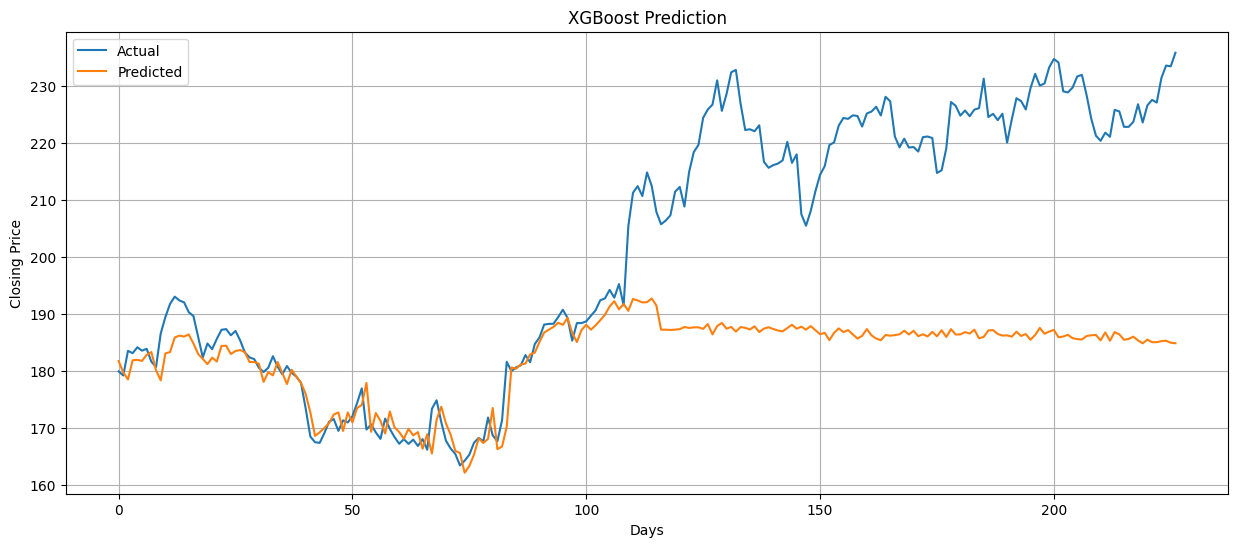

In [22]:
plt.figure(figsize=(15,6))

plt.plot(y_test.values,label="Actual")

plt.plot(predictions,label="Predicted")

plt.title("XGBoost Prediction")

plt.xlabel("Days")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

In [23]:
print("Training Close Range:")
print(y_train.min(), y_train.max())

print("Testing Close Range:")
print(y_test.min(), y_test.max())

Training Close Range:
35.17720413208008 195.89263916015625
Testing Close Range:
163.36141967773438 235.82330322265625


In [13]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

               Feature  Importance
1                  Low    0.305488
0                 High    0.201710
12                Lag1    0.167404
14                Lag3    0.166400
2                 Open    0.087462
15                Lag5    0.052122
5                 MA20    0.008372
13                Lag2    0.006224
6                 MA50    0.001702
4         Daily_Return    0.000675
16                 RSI    0.000378
18         Signal_Line    0.000300
10   Neutral_Sentiment    0.000293
11       article_count    0.000280
17                MACD    0.000274
7            Sentiment    0.000260
9   Negative_Sentiment    0.000222
8   Positive_Sentiment    0.000220
3               Volume    0.000214


In [24]:
print(df[['Close', 'Target']].tail(10))

           Close      Target
1122  222.806473  223.690811
1123  223.690811  226.771149
1124  226.771149  223.571594
1125  223.571594  226.572433
1126  226.830750  227.546204
1127  227.546204  227.069260
1128  228.410660  231.391617
1129  231.391617  233.567719
1130  233.567719  233.438538
1131  233.438538  235.823303


In [25]:
print("Training Target Range")
print(y_train.min(), y_train.max())

print("Testing Target Range")
print(y_test.min(), y_test.max())

Training Target Range
35.17720413208008 195.89263916015625
Testing Target Range
163.36141967773438 235.82330322265625


In [26]:
print(X_train.tail())

print(X_test.head())

          Close        Open        High         Low    Volume  Daily_Return  \
900  190.889267  191.442997  191.719862  190.671728  28919300     -0.002841   
901  190.988113  190.335512  191.334202  188.951173  48087700      0.000518   
902  191.413330  191.967060  192.481244  191.007915  34049900      0.002226   
903  190.375076  191.729738  192.224141  189.584027  42672100     -0.005424   
904  183.562195  185.055288  186.330858  181.831782  82488700     -0.035787   

           MA20        MA50        Lag1        Lag2        Lag3        Lag5  \
900  191.662010  183.517913  191.433090  192.500992  192.649353  193.697464   
901  191.797970  183.807932  190.889267  191.433090  192.500992  194.735703   
902  192.006114  184.137464  190.988113  190.889267  191.433090  192.649353   
903  192.133671  184.472104  191.413330  190.988113  190.889267  192.500992   
904  191.856804  184.677990  190.375076  191.413330  190.988113  191.433090   

           RSI      MACD  Signal_Line  Sentiment  

In [27]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(905, 20)
(905,)
(227, 20)
(227,)


In [28]:
print(df[['Sentiment',
          'Positive_Sentiment',
          'Negative_Sentiment',
          'Neutral_Sentiment',
          'article_count']].describe())

         Sentiment  Positive_Sentiment  Negative_Sentiment  Neutral_Sentiment  \
count  1132.000000         1132.000000         1132.000000        1132.000000   
mean      0.528199            0.097408            0.039040           0.863554   
std       0.301629            0.026005            0.018703           0.027994   
min      -0.993000            0.000000            0.000000           0.666500   
25%       0.411069            0.083000            0.027593           0.850669   
50%       0.550548            0.095319            0.036472           0.864136   
75%       0.685809            0.110023            0.047122           0.877363   
max       1.000000            0.289000            0.157000           1.000000   

       article_count  
count    1132.000000  
mean       23.469081  
std        15.953179  
min         1.000000  
25%        14.000000  
50%        22.000000  
75%        31.250000  
max       119.000000  


In [29]:
print(df.dtypes)

Date                      str
Close                 float64
High                  float64
Low                   float64
Open                  float64
Volume                  int64
Daily_Return          float64
MA20                  float64
MA50                  float64
Target                float64
Sentiment             float64
Positive_Sentiment    float64
Negative_Sentiment    float64
Neutral_Sentiment     float64
article_count         float64
Lag1                  float64
Lag2                  float64
Lag3                  float64
Lag5                  float64
RSI                   float64
MACD                  float64
Signal_Line           float64
dtype: object


In [30]:
df["Target"] = df["Close"].pct_change().shift(-1)

In [31]:
print(df.dtypes)

print(df.corr(numeric_only=True)['Target'].sort_values(ascending=False))

Date                      str
Close                 float64
High                  float64
Low                   float64
Open                  float64
Volume                  int64
Daily_Return          float64
MA20                  float64
MA50                  float64
Target                float64
Sentiment             float64
Positive_Sentiment    float64
Negative_Sentiment    float64
Neutral_Sentiment     float64
article_count         float64
Lag1                  float64
Lag2                  float64
Lag3                  float64
Lag5                  float64
RSI                   float64
MACD                  float64
Signal_Line           float64
dtype: object
Target                1.000000
Volume                0.071349
Negative_Sentiment    0.068827
Neutral_Sentiment     0.017860
RSI                  -0.008421
MACD                 -0.030367
Signal_Line          -0.030572
Sentiment            -0.057173
article_count        -0.063560
Positive_Sentiment   -0.068714
Daily_Return    

In [32]:
print(df[['Date', 'Close', 'Target']].head(10))

         Date      Close    Target
0  2017-10-05  36.193485  0.124370
1  2017-11-27  40.694866 -0.012867
2  2017-11-30  40.171238 -0.025720
3  2018-01-31  39.138016  0.067586
4  2018-03-16  41.783184 -0.054376
5  2018-03-27  39.511196  0.044434
6  2018-04-16  41.266819  0.055813
7  2018-06-22  43.570045  0.208691
8  2018-10-23  52.662727 -0.195425
9  2018-11-30  42.371140 -0.203774


In [33]:
print(df[['Close', 'Daily_Return', 'Target']].head(10))

       Close  Daily_Return    Target
0  36.193485      0.012445  0.124370
1  40.694866     -0.005029 -0.012867
2  40.171238      0.013984 -0.025720
3  39.138016      0.002755  0.067586
4  41.783184     -0.003526 -0.054376
5  39.511196     -0.025641  0.044434
6  41.266819      0.006238  0.055813
7  43.570045     -0.002912  0.208691
8  52.662727      0.009427 -0.195425
9  42.371140     -0.005402 -0.203774


In [34]:
print(df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return',
       'MA20', 'MA50', 'Target', 'Sentiment', 'Positive_Sentiment',
       'Negative_Sentiment', 'Neutral_Sentiment', 'article_count', 'Lag1',
       'Lag2', 'Lag3', 'Lag5', 'RSI', 'MACD', 'Signal_Line'],
      dtype='str')


In [35]:
# Remove the incorrect Target column
df = df.drop(columns=['Target'])

# Create the correct Target (next day's Close price)
df['Target'] = df['Close'].shift(-1)

# Remove the last row (no next day's Close available)
df = df.dropna().reset_index(drop=True)

In [36]:
print(df[['Date', 'Close', 'Target']].head(10))

         Date      Close     Target
0  2017-10-05  36.193485  40.694866
1  2017-11-27  40.694866  40.171238
2  2017-11-30  40.171238  39.138016
3  2018-01-31  39.138016  41.783184
4  2018-03-16  41.783184  39.511196
5  2018-03-27  39.511196  41.266819
6  2018-04-16  41.266819  43.570045
7  2018-06-22  43.570045  52.662727
8  2018-10-23  52.662727  42.371140
9  2018-11-30  42.371140  33.736988


In [37]:
print(df[['Close', 'Target']].corr())

           Close    Target
Close   1.000000  0.997528
Target  0.997528  1.000000
